In [1]:
import numpy as np
import networkx as nx
from networkx.algorithms.isomorphism import GraphMatcher
import matplotlib.pyplot as plt
import random
import sys
sys.path.insert(0, '.')
from checkers import (
  C3Checker, C4Checker, C3C4Checker, C6Checker,
  K23Checker, Theta123Checker, BullChecker, BowTieChecker
)

In [ ]:
def make_forbidden_graphs():
  bowtie = nx.Graph()
  bowtie.add_edges_from([(0,1),(1,2),(0,2),(2,3),(3,4),(2,4)])

  theta = nx.Graph()
  theta.add_edges_from([(0,1),(0,2),(2,1),(0,3),(3,4),(4,1)])

  return {
    'C3':     nx.cycle_graph(3),
    'C4':     nx.cycle_graph(4),
    'K23':    nx.complete_bipartite_graph(2, 3),
    'Bull':   nx.bull_graph(),
    'BowTie': bowtie,
    'Theta123': theta,
  }

FORBIDDEN = make_forbidden_graphs()

def brute_force(adj, name):
  H = FORBIDDEN[name]
  n = len(adj)
  h_nodes = list(H.nodes())
  h_edges = list(H.edges())
  k = len(h_nodes)
  from itertools import permutations
  for perm in permutations(range(n), k):
    mapping = {h_nodes[i]: perm[i] for i in range(k)}
    if all(adj[mapping[u]][mapping[v]] for u, v in h_edges):
      return True
  return False

CHECKERS = {
  'C3':       lambda n: C3Checker(n),
  'C4':       lambda n: C4Checker(n),
  'K23':      lambda n: K23Checker(n),
  'Bull':     lambda n: BullChecker(n),
  'BowTie':   lambda n: BowTieChecker(n),
  'Theta123': lambda n: Theta123Checker(n),
}

In [3]:
def stress_test(name, n=15, n_trials=200, seed=42, draw_failures=True):
  random.seed(seed)
  np.random.seed(seed)
  checker = CHECKERS[name](n)

  fp = 0  # false positives: checker fired, brute force disagrees
  fn = 0  # false negatives: brute force fired, checker missed
  total_edges = 0
  failure_adjs = []

  edges = [(i, j) for i in range(n) for j in range(i+1, n)]

  for trial in range(n_trials):
    adj  = np.zeros((n, n), dtype=bool)
    random.shuffle(edges)
    done = False

    for u, v in edges:
      if done: break
 

      ours   = checker.check(adj, u, v)
      adj[u][v] = adj[v][u] = True
      total_edges += 1
      ground = brute_force(adj, name)

      if ours and not ground:
        fp += 1
        if draw_failures: failure_adjs.append(('FP', adj.copy(), u, v, trial))
      if ground and not ours:
        fn += 1
        if draw_failures: failure_adjs.append(('FN', adj.copy(), u, v, trial))

      if ground:
        done = True

  print(f'{name:10s}  n={n}  trials={n_trials}  edges_checked={total_edges}')
  print(f'  false positives: {fp}')
  print(f'  false negatives: {fn}')
  print(f'  {"PASS" if fp==0 and fn==0 else "FAIL"}')

  if failure_adjs:
    print(f'  drawing first failure...')
    kind, adj_f, u, v, trial = failure_adjs[0]
    G = nx.from_numpy_array(adj_f.astype(float))
    fig, ax = plt.subplots(figsize=(5, 5))
    pos = nx.spring_layout(G, seed=0)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color='#1D9E75',
            node_size=500, font_color='white', edge_color='#444')
    ax.set_title(f'{kind} — {name}  trial={trial}  last edge=({u},{v})')
    plt.show()

  return fp, fn

C3          n=8  trials=300  edges_checked=2242
  false positives: 0
  false negatives: 0
  PASS

C4          n=8  trials=300  edges_checked=2400
  false positives: 0
  false negatives: 0
  PASS

C6          n=8  trials=300  edges_checked=3059
  false positives: 0
  false negatives: 26
  FAIL
  drawing first failure...


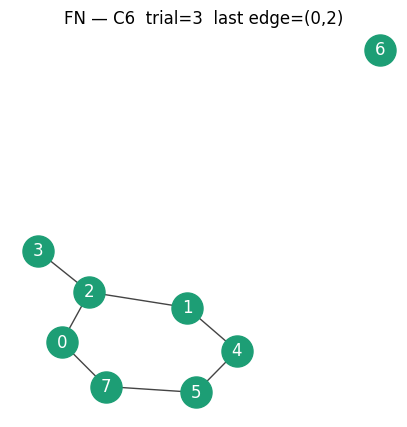


K23         n=8  trials=300  edges_checked=3431
  false positives: 0
  false negatives: 0
  PASS

Bull        n=8  trials=300  edges_checked=2452
  false positives: 0
  false negatives: 0
  PASS

BowTie      n=8  trials=300  edges_checked=3334
  false positives: 0
  false negatives: 0
  PASS

Theta123    n=8  trials=300  edges_checked=2868
  false positives: 0
  false negatives: 0
  PASS



In [4]:
results = {}
for name in CHECKERS:
  fp, fn = stress_test(name, n=8, n_trials=300)
  results[name] = (fp, fn)
  print()

In [5]:
print('\n=== SUMMARY ===')
all_pass = True
for name, (fp, fn) in results.items():
  status = 'PASS' if fp==0 and fn==0 else 'FAIL'
  if status == 'FAIL': all_pass = False
  print(f'  {name:10s}  fp={fp}  fn={fn}  {status}')
print(f'\noverall: {"ALL PASS" if all_pass else "FAILURES EXIST"}')


=== SUMMARY ===
  C3          fp=0  fn=0  PASS
  C4          fp=0  fn=0  PASS
  C6          fp=0  fn=26  FAIL
  K23         fp=0  fn=0  PASS
  Bull        fp=0  fn=0  PASS
  BowTie      fp=0  fn=0  PASS
  Theta123    fp=0  fn=0  PASS

overall: FAILURES EXIST


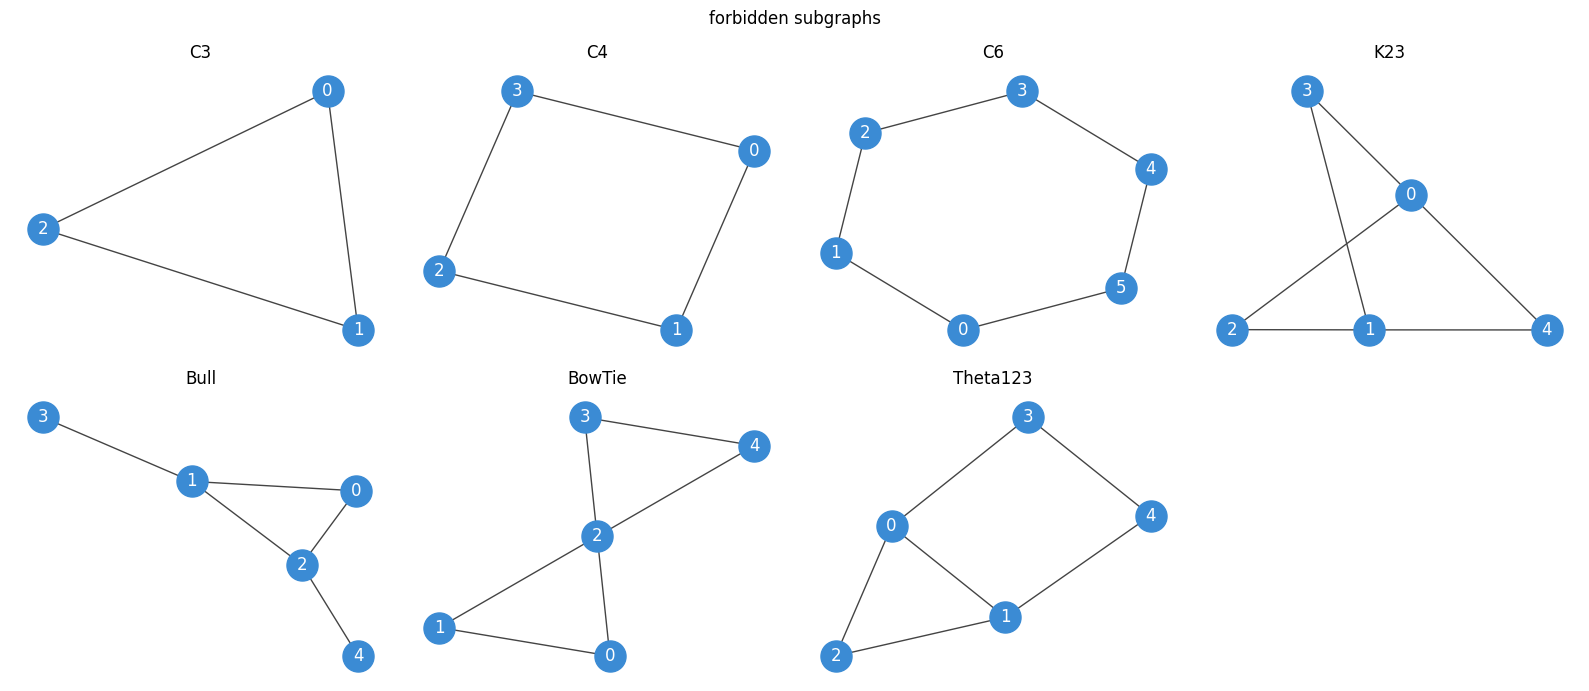

In [6]:
# draw the forbidden graphs themselves for reference
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, (name, H) in enumerate(FORBIDDEN.items()):
  ax  = axes[i]
  pos = nx.spring_layout(H, seed=0)
  nx.draw(H, pos, ax=ax, with_labels=True, node_color='#3B8BD4',
          node_size=500, font_color='white', edge_color='#444')
  ax.set_title(name)
axes[-1].axis('off')
plt.suptitle('forbidden subgraphs', fontsize=12)
plt.tight_layout()
plt.show()